In [1]:
import sys
sys.path.append("/user/christoph.wald/u15287/insect_pest_detection/modules")
from modules_segmentation import *
from modules_prediction import *
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import cv2
import numpy as np

In [2]:
#load image file
images_masked = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/03_images_masked"
file_list = os.listdir(images_masked)


#image_file = random.choice(file_list)#
image_file = "BRAIIM_0268.jpg"
print(image_file)
images_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/04_images_cropped" 
labels_folder ="/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/04_labels_cropped"
image = cv2.imread(os.path.join(images_folder, image_file))
image_masked = cv2.imread(os.path.join(images_masked, image_file))

    
#recangles
if "TRIAVA" in image_file:
    min_area_contour = 100 
    max_area_contour = 2000
    scale = 1.5
    max_ratio = 2 
    upper_limit_rectangles = None
    value_threshold =97 # 5th percentile
    binary_default = False
elif "LIRIBO" in image_file: 
    min_area_contour = 1000 
    max_area_contour = 10000 
    scale = 1.5
    max_ratio = 1.76 #95th percentile
    upper_limit_rectangles = 28530 #22340 #95th percentile
    value_threshold = None
    binary_default = True
elif "BRAIIM" in image_file:
    min_area_contour = 2000 
    max_area_contour = 10000
    scale = 1.5
    max_ratio = 1.73 #1.75 #95the percentile
    upper_limit_rectangles = 42970 #41703 #95th percentil
    value_threshold = None
    binary_default = True

rectangles, v = get_list_of_rectangles(image_masked, min_area_contour, max_area_contour, scale, max_ratio, upper_limit_rectangles, value_threshold, binary_default)

if "TRIAVA" in image_file:
    rectangles = remove_smaller_overlaps(rectangles)

#convert xywh -> xyxy
rectangles = [(x, y, x + w, y + h) for (x, y, w, h) in rectangles]

BRAIIM_0268.jpg
using only simple binarization.


In [3]:
print(len(rectangles))

32


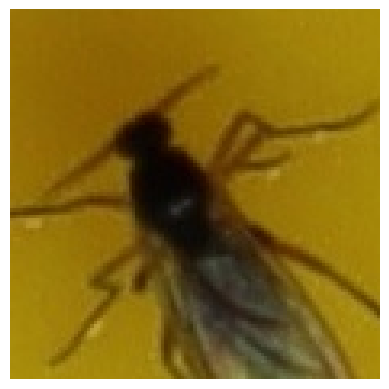

In [6]:
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
box = rectangles[0]
x1, y1, x2, y2 = map(int, box)
region_bgr = image[y1:y2, x1:x2]
region_hsv = hsv_image[y1:y2, x1:x2]
plt.imshow(cv2.cvtColor(region_bgr, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

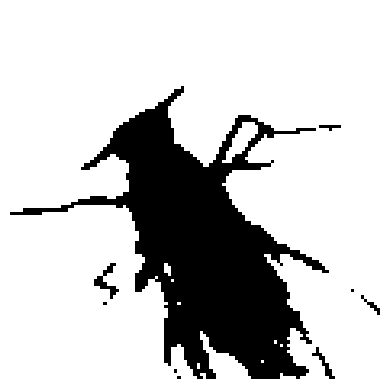

In [41]:
value = region_hsv[:, :, 2]

# --- Otsu threshold ---
otsu_thresh, binary_mask = cv2.threshold(value, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(binary_mask, cmap= "gray")
plt.axis("off")
plt.show()

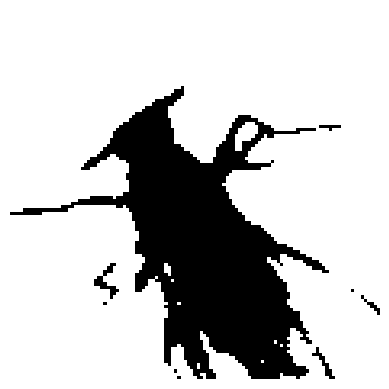

In [39]:
 # Assume region is your HSV patch
h_channel = region_hsv[:, :, 0]  # Hue channel in OpenCV (0-179)

# Create hue filter mask
hue_mask = (h_channel > 18).astype(np.uint8)  # 1 for pixels >= 36, 0 otherwise

plt.imshow(hue_mask, cmap = "gray")

# Assume binary_mask is your existing mask (0 or 255)
binary_mask_bool = (binary_mask > 0).astype(np.uint8)  # convert to 0/1

# Combine masks
combined_mask = binary_mask_bool * hue_mask  # AND operation
combined_mask = combined_mask * 255  # convert back to 0-255 for display


plt.imshow(combined_mask, cmap = "gray")
plt.axis("off")
plt.show()

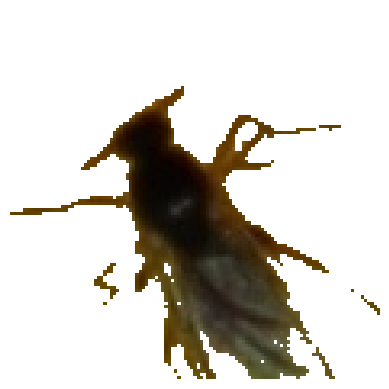

In [42]:
binary_mask_inv = cv2.bitwise_not(combined_mask)  # foreground=255, background=0

# Apply mask to the region_bgr
foreground = cv2.bitwise_and(region_bgr, region_bgr, mask=binary_mask_inv)

# Optional: set background to white
background = np.full_like(region_bgr, 255)  # white background
result = np.where(binary_mask_inv[:, :, np.newaxis] == 0, background, foreground)

# Show result
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:

        # --- 2) Value histogram ---
        axes[idx, 1].hist(value.ravel(), bins=50, color='gray', alpha=0.7)
        axes[idx, 1].axvline(otsu_thresh, color='r', linestyle='--', label=f"Otsu = {otsu_thresh:.1f}")
        axes[idx, 1].set_title("Value Histogram + Otsu Threshold")
        axes[idx, 1].set_xlabel("Value")
        axes[idx, 1].set_ylabel("Pixel Count")
        axes[idx, 1].legend()

        # --- 3) Binary mask ---
        axes[idx, 2].imshow(binary_mask, cmap='gray')
        axes[idx, 2].set_title("Binary Mask (Otsu)")
        axes[idx, 2].axis("off")

        # --- 4) Segmented region ---
        '''
        mask_3ch = cv2.merge([binary_mask, binary_mask, binary_mask])
        segmented = cv2.bitwise_and(region_bgr, mask_3ch)
        axes[idx, 3].imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
        axes[idx, 3].set_title("Segmented Foreground")
        axes[idx, 3].axis("off")
        '''

        segmented_pixels = np.zeros_like(region_bgr)
        #segmented_pixels[binary_mask > 0] = region_bgr[binary_mask > 0]

        # Show
        axes[idx, 3].imshow(cv2.cvtColor(segmented_pixels, cv2.COLOR_BGR2RGB))
        axes[idx, 3].set_title("Segmented Foreground")
        axes[idx, 3].axis("off")


    plt.tight_layout()
    save_path = os.path.join(output_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Otsu segmentation grid saved to: {save_path}")
